# 📦 Part 2: Data Preparation & Augmentation

**Author:** [Dominikus Krisna Herlambang](https://www.linkedin.com/in/dominikus-krisna-herlambang)<br>
**Date created:** 2021<br>
**Last modified:** 2021<br>

## 🔧 Setup & Installation

In [ ]:
# Install dependencies
!pip install -q torch torchvision pillow matplotlib numpy scikit-learn

print("✅ Installation complete!")

✅ Installation complete!


In [ ]:
# Import libraries
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import shutil
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("📦 PyTorch version:", torch.__version__)
print("📦 Torchvision version:", torchvision.__version__)
print("✅ All imports successful!")

📦 PyTorch version: 2.9.0+cu126
📦 Torchvision version: 0.24.0+cu126
✅ All imports successful!


---
## 📁 Section 1: Dataset Organization

Proper folder structure is key to efficient data loading!

### 📥 Download Sample Dataset

For this lab, we will use sample food images.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arizbw/traditional-food-knowledge-of-indonesia")

print("Path to dataset files:", path)

# Create destination directory
os.makedirs('/content/food_dataset', exist_ok=True)

# Move the entire downloaded directory to your target location
shutil.copytree(path, '/content/food_dataset', dirs_exist_ok=True)

print("Files moved to /content/food_dataset")

100%|██████████| 3.10G/3.10G [02:21<00:00, 23.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arizbw/traditional-food-knowledge-of-indonesia/versions/3
Files moved to /content/food_dataset


In [ ]:
import pandas as pd
import os
import shutil
from pathlib import Path
from tqdm import tqdm

# Paths
csv_train = '/content/food_dataset/train.csv'
csv_test = '/content/food_dataset/test.csv'
csv_val = '/content/food_dataset/dev.csv'

images_path = '/content/food_dataset/food-tfk-images'
base_dir = '/content/food_dataset'

# Load CSV files
data_train = pd.read_csv(csv_train)
data_test = pd.read_csv(csv_test)
data_val = pd.read_csv(csv_val)

print("📊 Dataset Info:")
print(f"Train: {len(data_train)} images")
print(f"Test: {len(data_test)} images")
print(f"Val: {len(data_val)} images")
print(f"\n🔍 Train columns: {list(data_train.columns)}")
print(f"\nFirst few rows of train data:")
print(data_train.head())

# Function to move images
def move_images_to_folders(df, split_name, images_path, base_dir):
    """
    Move images from source to organized folder structure

    Args:
        df: DataFrame with image information
        split_name: 'train', 'test', or 'val'
        images_path: Source path of images
        base_dir: Base directory for organized dataset
    """
    print(f"\n🚀 Moving {split_name} images...")

    moved = 0
    failed = 0
    skipped = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        # Get image filename and label
        image_file = row['Image Index']
        label = row['Finding Labels']  # Adjust this column name if different

        # Source path
        source_path = os.path.join(images_path, image_file)

        # Destination path
        dest_dir = os.path.join(base_dir, split_name, label)
        dest_path = os.path.join(dest_dir, image_file)

        # Check if source exists
        if not os.path.exists(source_path):
            failed += 1
            continue

        # Check if already moved
        if os.path.exists(dest_path):
            skipped += 1
            continue

        # Create directory if not exists
        os.makedirs(dest_dir, exist_ok=True)

        # Copy file (use shutil.move to move instead of copy)
        try:
            shutil.copy2(source_path, dest_path)
            moved += 1
        except Exception as e:
            print(f"Error moving {image_file}: {e}")
            failed += 1

    print(f"✅ {split_name}: Moved={moved}, Skipped={skipped}, Failed={failed}")
    return moved, skipped, failed

# Move all images
print("\n" + "="*60)
print("📦 Starting image organization...")
print("="*60)

stats = {}
stats['train'] = move_images_to_folders(data_train, 'train', images_path, base_dir)
stats['val'] = move_images_to_folders(data_val, 'val', images_path, base_dir)
stats['test'] = move_images_to_folders(data_test, 'test', images_path, base_dir)

# Summary
print("\n" + "="*60)
print("📊 SUMMARY")
print("="*60)
total_moved = sum(s[0] for s in stats.values())
total_skipped = sum(s[1] for s in stats.values())
total_failed = sum(s[2] for s in stats.values())

print(f"✅ Total moved: {total_moved}")
print(f"⏭️  Total skipped: {total_skipped}")
print(f"❌ Total failed: {total_failed}")

# Verify organization
print("\n🔍 Verifying folder contents...")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_dir, split)
    if os.path.exists(split_path):
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                count = len(os.listdir(class_path))
                print(f"  {split}/{class_name}: {count} images")

📊 Dataset Info:
Train: 1150 images
Test: 329 images
Val: 164 images

🔍 Train columns: ['Image Index', 'Patient ID', 'Finding Labels', 'asinan-jakarta', 'ayam-betutu', 'ayam-bumbu-rujak', 'ayam-goreng-lengkuas', 'bika-ambon', 'bir-pletok', 'bubur-manado', 'cendol', 'es-dawet', 'gado-gado', 'gudeg', 'gulai-ikan-mas', 'keladi', 'kerak-telor', 'klappertart', 'kolak', 'kue-lumpur', 'kunyit-asam', 'laksa-bogor', 'lumpia-semarang', 'mie-aceh', 'nagasari', 'nasi-goreng-kampung', 'papeda', 'pempek-palembang', 'rawon-surabaya', 'rendang', 'rujak-cingur', 'sate-ayam-madura', 'sate-lilit', 'sate-maranggi', 'soerabi', 'soto-ayam-lamongan', 'soto-banjar', 'tahu-telur']

First few rows of train data:
    Image Index  Patient ID Finding Labels  asinan-jakarta  ayam-betutu  \
0  IMG_6886.jpg           1      gado-gado               0            0   
1  IMG_7701.jpg           1    soto-banjar               0            0   
2  IMG_7023.jpg           1   rujak-cingur               0            0   
3  IM

Processing train: 100%|██████████| 1150/1150 [00:17<00:00, 65.62it/s]


✅ train: Moved=1150, Skipped=0, Failed=0

🚀 Moving val images...


Processing val: 100%|██████████| 164/164 [00:03<00:00, 48.85it/s]


✅ val: Moved=164, Skipped=0, Failed=0

🚀 Moving test images...


Processing test: 100%|██████████| 329/329 [00:03<00:00, 86.29it/s]

✅ test: Moved=329, Skipped=0, Failed=0

📊 SUMMARY
✅ Total moved: 1643
⏭️  Total skipped: 0
❌ Total failed: 0

🔍 Verifying folder contents...
  train/rujak-cingur: 38 images
  train/soto-banjar: 39 images
  train/kolak: 37 images
  train/bubur-manado: 33 images
  train/gulai-ikan-mas: 38 images
  train/rendang: 32 images
  train/nagasari: 66 images
  train/kunyit-asam: 22 images
  train/tahu-telur: 27 images
  train/lumpia-semarang: 31 images
  train/kerak-telor: 33 images
  train/asinan-jakarta: 43 images
  train/keladi: 36 images
  train/bika-ambon: 28 images
  train/laksa-bogor: 33 images
  train/rawon-surabaya: 38 images
  train/cendol: 32 images
  train/soto-ayam-lamongan: 27 images
  train/ayam-betutu: 34 images
  train/es-dawet: 27 images
  train/ayam-goreng-lengkuas: 29 images
  train/sate-ayam-madura: 37 images
  train/gado-gado: 39 images
  train/soerabi: 30 images
  train/gudeg: 25 images
  train/klappertart: 35 images
  train/bir-pletok: 25 images
  train/ayam-bumbu-rujak: 3

---
## 🔀 Section 2: Train/Val/Test Split

Best practice: 70% train, 15% validation, 15% test

### 🎯 Exp 1: Verify Split

**Task:** Check class balance across splits

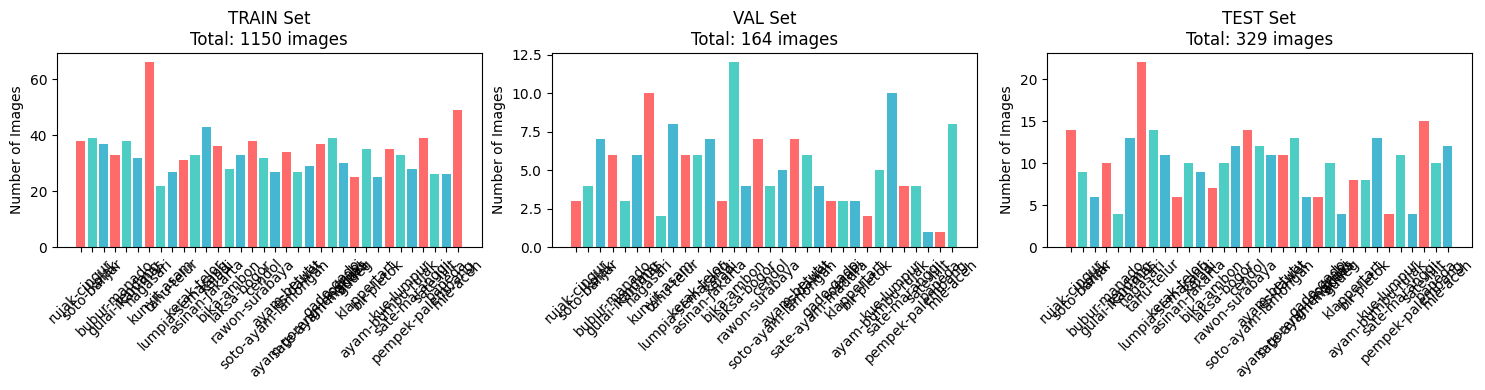


📊 Dataset Summary:

TRAIN:
  rujak-cingur: 38 images (3.3%)
  soto-banjar: 39 images (3.4%)
  kolak: 37 images (3.2%)
  bubur-manado: 33 images (2.9%)
  gulai-ikan-mas: 38 images (3.3%)
  rendang: 32 images (2.8%)
  nagasari: 66 images (5.7%)
  kunyit-asam: 22 images (1.9%)
  tahu-telur: 27 images (2.3%)
  lumpia-semarang: 31 images (2.7%)
  kerak-telor: 33 images (2.9%)
  asinan-jakarta: 43 images (3.7%)
  keladi: 36 images (3.1%)
  bika-ambon: 28 images (2.4%)
  laksa-bogor: 33 images (2.9%)
  rawon-surabaya: 38 images (3.3%)
  cendol: 32 images (2.8%)
  soto-ayam-lamongan: 27 images (2.3%)
  ayam-betutu: 34 images (3.0%)
  es-dawet: 27 images (2.3%)
  ayam-goreng-lengkuas: 29 images (2.5%)
  sate-ayam-madura: 37 images (3.2%)
  gado-gado: 39 images (3.4%)
  soerabi: 30 images (2.6%)
  gudeg: 25 images (2.2%)
  klappertart: 35 images (3.0%)
  bir-pletok: 25 images (2.2%)
  ayam-bumbu-rujak: 35 images (3.0%)
  kue-lumpur: 33 images (2.9%)
  sate-maranggi: 28 images (2.4%)
  pempek-pa

In [ ]:
def verify_dataset_split(dataset_dir):
    """
    Verify and visualize dataset split distribution
    """
    splits = ['train', 'val', 'test']
    classes = os.listdir(os.path.join(dataset_dir, 'train'))

    # Count images per class per split
    data = {split: {} for split in splits}

    for split in splits:
        for class_name in classes:
            class_dir = os.path.join(dataset_dir, split, class_name)
            if os.path.exists(class_dir):
                count = len(os.listdir(class_dir))
                data[split][class_name] = count

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for idx, split in enumerate(splits):
        classes_list = list(data[split].keys())
        counts = list(data[split].values())

        axes[idx].bar(classes_list, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
        axes[idx].set_title(f'{split.upper()} Set\nTotal: {sum(counts)} images')
        axes[idx].set_ylabel('Number of Images')
        axes[idx].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n📊 Dataset Summary:")
    for split in splits:
        total = sum(data[split].values())
        print(f"\n{split.upper()}:")
        for class_name, count in data[split].items():
            percentage = (count / total * 100) if total > 0 else 0
            print(f"  {class_name}: {count} images ({percentage:.1f}%)")

# TODO: Run this function after splitting your dataset
verify_dataset_split('/content/food_dataset')

---
## 🎨 Section 3: Data Augmentation

**Why augment?**
- Small dataset → Need more variety
- Prevent overfitting
- Simulate real-world conditions

In [ ]:
# Define augmentation transforms
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),                    # Resize to larger size first
    transforms.RandomCrop(224),                       # Random crop to 224×224
    transforms.RandomHorizontalFlip(p=0.5),           # 50% chance horizontal flip
    transforms.RandomRotation(degrees=30),            # Random rotation ±30°
    transforms.ColorJitter(
        brightness=0.2,                               # ±20% brightness
        contrast=0.2,                                 # ±20% contrast
        saturation=0.2,                               # ±20% saturation
        hue=0.1                                       # ±10% hue
    ),
    transforms.RandomAffine(                          # Random affine transformations
        degrees=0,
        translate=(0.1, 0.1),                        # ±10% translation
        scale=(0.9, 1.1)                             # 90-110% scale
    ),
    transforms.ToTensor(),                            # Convert to tensor
    transforms.Normalize(                             # ImageNet statistics
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms (NO augmentation!)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),                    # Just resize
    transforms.ToTensor(),                            # Convert to tensor
    transforms.Normalize(                             # Same normalization
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms defined!")
print("\n📝 Training transforms:")
print(train_transforms)
print("\n📝 Validation transforms:")
print(val_transforms)

✅ Transforms defined!

📝 Training transforms:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), scale=(0.9, 1.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

📝 Validation transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 🎨 Visualize Augmentations

Let's see what augmentation does to our images!

📤 Upload a sample image to see augmentations...


Saving 20250329205944list_mobil_daihatsu_bekas.webp to 20250329205944list_mobil_daihatsu_bekas.webp


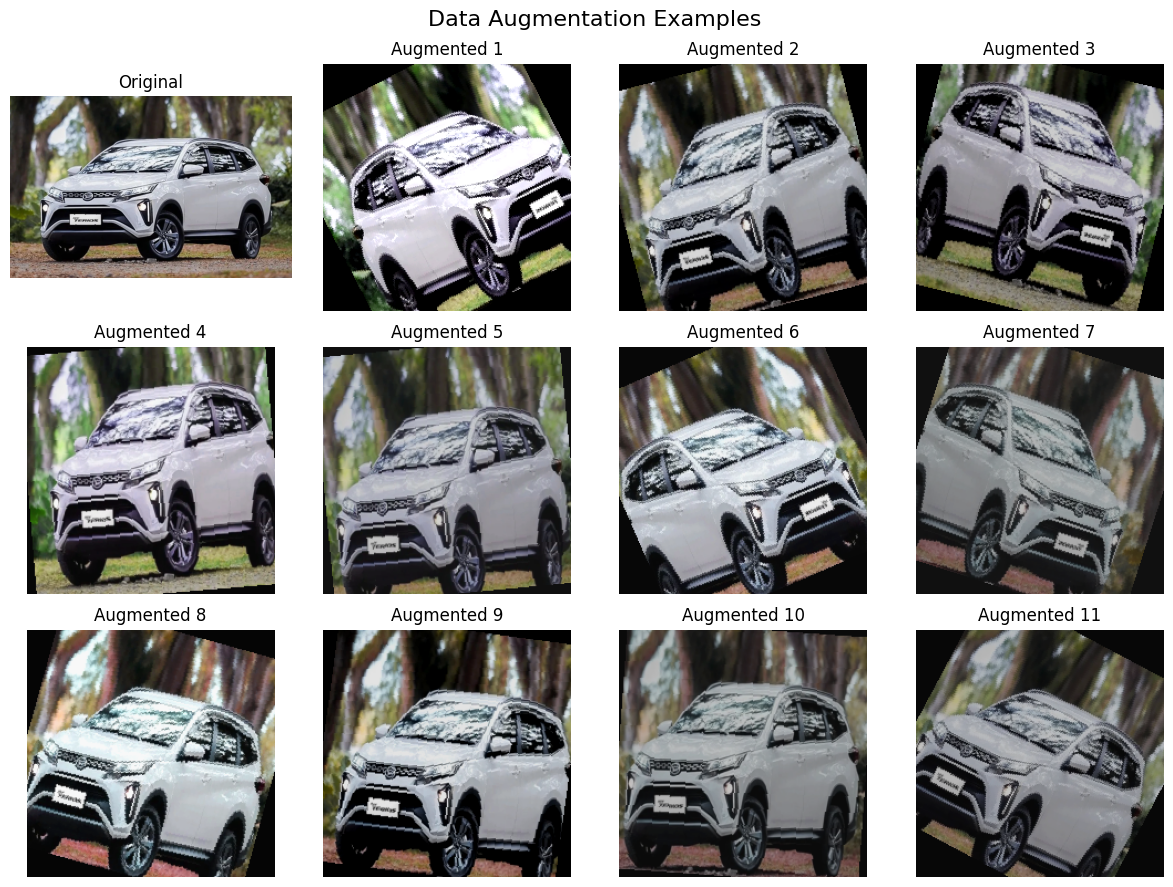


✅ Notice how each augmented image is different!
   This creates variety from a single image.


In [ ]:
from google.colab import files

# Upload a sample image
print("📤 Upload a sample image to see augmentations...")
uploaded = files.upload()
sample_img_path = list(uploaded.keys())[0]

# Load image
sample_img = Image.open(sample_img_path).convert('RGB')

# Define transform without normalization (for visualization)
aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

# Generate multiple augmented versions
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

# Original
axes[0].imshow(sample_img)
axes[0].set_title('Original')
axes[0].axis('off')

# Augmented versions
for i in range(1, 12):
    aug_img = aug_transform(sample_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=16)
plt.tight_layout()
plt.show()

print("\n✅ Notice how each augmented image is different!")
print("   This creates variety from a single image.")

### 🎯 Exp 2: Custom Augmentation

**Task:** Create your own augmentation pipeline!

In [ ]:
from torchvision import transforms

def create_custom_augmentation():
    """
    Create custom augmentation pipeline with:
    1. Random horizontal flip (p=0.5)
    2. Random rotation (±15 degrees)
    3. Color jitter (brightness, contrast)
    4. Normalize with ImageNet stats
    """

    custom_transform = transforms.Compose([
        # 1. Random horizontal flip
        transforms.RandomHorizontalFlip(p=0.5),

        # 2. Random rotation ±15 degrees
        transforms.RandomRotation(degrees=15),

        # 3. Color jitter
        transforms.ColorJitter(
            brightness=0.2,    # ±20% brightness
            contrast=0.2,      # ±20% contrast
            saturation=0.1,    # ±10% saturation
            hue=0.05           # ±5% hue
        ),

        # 4. Convert to Tensor
        transforms.ToTensor(),

        # 5. Normalize with ImageNet stats
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    print("✅ Custom augmentation pipeline created!")
    print("\n📋 Pipeline steps:")
    print("   1. RandomHorizontalFlip (p=0.5)")
    print("   2. RandomRotation (±15°)")
    print("   3. ColorJitter (brightness, contrast, saturation, hue)")
    print("   4. ToTensor")
    print("   5. Normalize (ImageNet stats)")

    return custom_transform

# Test your pipeline:
custom_aug = create_custom_augmentation()

✅ Custom augmentation pipeline created!

📋 Pipeline steps:
   1. RandomHorizontalFlip (p=0.5)
   2. RandomRotation (±15°)
   3. ColorJitter (brightness, contrast, saturation, hue)
   4. ToTensor
   5. Normalize (ImageNet stats)


---
## 📦 Section 4: PyTorch DataLoader

Efficient data loading is crucial for training!

In [ ]:
# Create datasets
def create_dataloaders(data_dir, batch_size=32, num_workers=2):
    """
    Create PyTorch DataLoaders for train/val/test

    Args:
        data_dir: Root directory with train/val/test folders
        batch_size: Batch size for training
        num_workers: Number of parallel workers

    Returns:
        Dictionary of DataLoaders and datasets
    """

    # Transforms
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Create datasets
    train_dataset = datasets.ImageFolder(
        root=os.path.join(data_dir, 'train'),
        transform=train_transform
    )

    val_dataset = datasets.ImageFolder(
        root=os.path.join(data_dir, 'val'),
        transform=val_transform
    )

    test_dataset = datasets.ImageFolder(
        root=os.path.join(data_dir, 'test'),
        transform=val_transform
    )

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,           # Shuffle training data
        num_workers=num_workers,
        pin_memory=True         # Faster data transfer to GPU
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,          # Don't shuffle val/test
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    # Print info
    print("✅ DataLoaders created!")
    print(f"\n📊 Dataset sizes:")
    print(f"   Train: {len(train_dataset)} images")
    print(f"   Val: {len(val_dataset)} images")
    print(f"   Test: {len(test_dataset)} images")
    print(f"\n📦 Batch size: {batch_size}")
    print(f"   Train batches: {len(train_loader)}")
    print(f"   Val batches: {len(val_loader)}")
    print(f"   Test batches: {len(test_loader)}")
    print(f"\n🏷️ Classes: {train_dataset.classes}")
    print(f"   Class to index: {train_dataset.class_to_idx}")

    return {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'train_dataset': train_dataset,
        'val_dataset': val_dataset,
        'test_dataset': test_dataset
    }

# Example usage (uncomment when you have data):
loaders = create_dataloaders(
    data_dir='/content/food_dataset',
    batch_size=32,
    num_workers=2
)

✅ DataLoaders created!

📊 Dataset sizes:
   Train: 1150 images
   Val: 164 images
   Test: 329 images

📦 Batch size: 32
   Train batches: 36
   Val batches: 6
   Test batches: 11

🏷️ Classes: ['asinan-jakarta', 'ayam-betutu', 'ayam-bumbu-rujak', 'ayam-goreng-lengkuas', 'bika-ambon', 'bir-pletok', 'bubur-manado', 'cendol', 'es-dawet', 'gado-gado', 'gudeg', 'gulai-ikan-mas', 'keladi', 'kerak-telor', 'klappertart', 'kolak', 'kue-lumpur', 'kunyit-asam', 'laksa-bogor', 'lumpia-semarang', 'mie-aceh', 'nagasari', 'papeda', 'pempek-palembang', 'rawon-surabaya', 'rendang', 'rujak-cingur', 'sate-ayam-madura', 'sate-lilit', 'sate-maranggi', 'soerabi', 'soto-ayam-lamongan', 'soto-banjar', 'tahu-telur']
   Class to index: {'asinan-jakarta': 0, 'ayam-betutu': 1, 'ayam-bumbu-rujak': 2, 'ayam-goreng-lengkuas': 3, 'bika-ambon': 4, 'bir-pletok': 5, 'bubur-manado': 6, 'cendol': 7, 'es-dawet': 8, 'gado-gado': 9, 'gudeg': 10, 'gulai-ikan-mas': 11, 'keladi': 12, 'kerak-telor': 13, 'klappertart': 14, 'kolak'

### 🔍 Inspect DataLoader Output

📦 Batch info:
   Images shape: torch.Size([32, 3, 224, 224])
   Labels shape: torch.Size([32])
   Data type: torch.float32
   Device: cpu
   Min value: -2.118
   Max value: 2.640


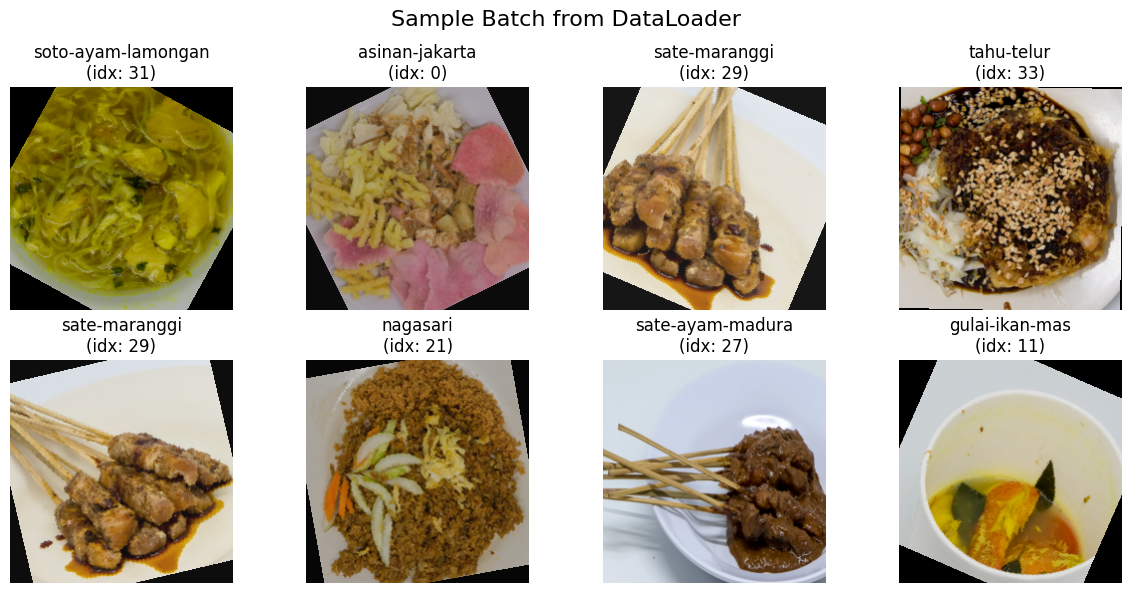

In [ ]:
def visualize_batch(dataloader, classes, num_images=8):
    """
    Visualize a batch from dataloader
    """
    # Get one batch
    images, labels = next(iter(dataloader))

    print(f"📦 Batch info:")
    print(f"   Images shape: {images.shape}")  # [batch_size, channels, height, width]
    print(f"   Labels shape: {labels.shape}")  # [batch_size]
    print(f"   Data type: {images.dtype}")
    print(f"   Device: {images.device}")
    print(f"   Min value: {images.min():.3f}")
    print(f"   Max value: {images.max():.3f}")

    # Denormalize for visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images_denorm = images * std + mean
    images_denorm = torch.clamp(images_denorm, 0, 1)

    # Plot
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    for idx in range(min(num_images, len(images))):
        img = images_denorm[idx].permute(1, 2, 0).numpy()  # CHW -> HWC
        label_idx = labels[idx].item()
        label_name = classes[label_idx]

        axes[idx].imshow(img)
        axes[idx].set_title(f"{label_name}\n(idx: {label_idx})")
        axes[idx].axis('off')

    plt.suptitle('Sample Batch from DataLoader', fontsize=16)
    plt.tight_layout()
    plt.show()

# Example usage:
visualize_batch(
    loaders['train_loader'],
    classes=loaders['train_dataset'].classes,
    num_images=8
)

---
## ⚖️ Section 5: Handling Class Imbalance

What if you have 1000 nasi_goreng but only 50 sate images?

### 🎯 Exp 3: Class Weights

**Task:** Calculate class weights for loss function

In [ ]:
import torch
from collections import Counter

def calculate_class_weights(dataset):
    """
    Calculate class weights for weighted loss

    Formula: weight = total_samples / (num_classes * class_count)

    Args:
        dataset: PyTorch ImageFolder dataset

    Returns:
        Tensor of class weights
    """

    # Count samples per class
    class_counts = Counter([label for _, label in dataset])

    # Total samples and classes
    total_samples = len(dataset)
    num_classes = len(dataset.classes)

    # Calculate weights
    weights = torch.zeros(num_classes)

    for class_idx in range(num_classes):
        class_count = class_counts[class_idx]

        # Weight formula: inversely proportional to frequency
        weights[class_idx] = total_samples / (num_classes * class_count)

    print("📊 Class Distribution:")
    for class_idx in range(num_classes):
        class_name = dataset.classes[class_idx]
        count = class_counts[class_idx]
        weight = weights[class_idx].item()
        print(f"   {class_name:15s}: {count:3d} samples (weight: {weight:.3f})")

    print(f"\n✅ Class weights calculated!")
    print(f"   Weights tensor: {weights}")

    return weights

# Test your function:
weights = calculate_class_weights(loaders['train_dataset'])
print(f"Class weights: {weights}")

# Use in loss function:
criterion = torch.nn.CrossEntropyLoss(weight=weights)

📊 Class Distribution:
   asinan-jakarta :  43 samples (weight: 0.787)
   ayam-betutu    :  34 samples (weight: 0.995)
   ayam-bumbu-rujak:  35 samples (weight: 0.966)
   ayam-goreng-lengkuas:  29 samples (weight: 1.166)
   bika-ambon     :  28 samples (weight: 1.208)
   bir-pletok     :  25 samples (weight: 1.353)
   bubur-manado   :  33 samples (weight: 1.025)
   cendol         :  32 samples (weight: 1.057)
   es-dawet       :  27 samples (weight: 1.253)
   gado-gado      :  39 samples (weight: 0.867)
   gudeg          :  25 samples (weight: 1.353)
   gulai-ikan-mas :  38 samples (weight: 0.890)
   keladi         :  36 samples (weight: 0.940)
   kerak-telor    :  33 samples (weight: 1.025)
   klappertart    :  35 samples (weight: 0.966)
   kolak          :  37 samples (weight: 0.914)
   kue-lumpur     :  33 samples (weight: 1.025)
   kunyit-asam    :  22 samples (weight: 1.537)
   laksa-bogor    :  33 samples (weight: 1.025)
   lumpia-semarang:  31 samples (weight: 1.091)
   mie-aceh 

---
## 🔍 Section 6: Data Quality Checks

Always verify your data before training!

In [ ]:
def verify_dataset_quality(data_dir):
    """
    Check for corrupted images and data quality issues
    """
    from PIL import Image

    corrupted_files = []
    small_images = []

    print("🔍 Checking dataset quality...")

    # Check all splits
    for split in ['train', 'val', 'test']:
        split_dir = os.path.join(data_dir, split)

        if not os.path.exists(split_dir):
            continue

        print(f"\n📂 Checking {split} set...")

        for class_name in os.listdir(split_dir):
            class_dir = os.path.join(split_dir, class_name)

            if not os.path.isdir(class_dir):
                continue

            for img_file in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_file)

                try:
                    # Try to open image
                    with Image.open(img_path) as img:
                        # Check size
                        width, height = img.size

                        if width < 100 or height < 100:
                            small_images.append(img_path)

                        # Try to load
                        img.verify()

                except Exception as e:
                    corrupted_files.append((img_path, str(e)))

    # Report
    print("\n✅ Quality check complete!")

    if corrupted_files:
        print(f"\n⚠️ Found {len(corrupted_files)} corrupted files:")
        for path, error in corrupted_files[:5]:  # Show first 5
            print(f"   {path}")
            print(f"   Error: {error}")
    else:
        print("\n✅ No corrupted files found!")

    if small_images:
        print(f"\n⚠️ Found {len(small_images)} images smaller than 100×100")
        for path in small_images[:5]:  # Show first 5
            print(f"   {path}")
    else:
        print("\n✅ All images have acceptable sizes!")

    return corrupted_files, small_images

# Run quality check:
corrupted, small = verify_dataset_quality('/content/food_dataset')

🔍 Checking dataset quality...

📂 Checking train set...

📂 Checking val set...

📂 Checking test set...

✅ Quality check complete!

✅ No corrupted files found!

✅ All images have acceptable sizes!
